In [2]:
import pandas as pd
import numpy as np
from Bio import SeqIO
import matplotlib.pyplot as plt
import scipy.stats as stats

In [3]:
def summarise_distribution(contig_file):
    seqs = list(SeqIO.parse(open(contig_file), "fasta"))
    lens = [len(x.seq) for x in seqs]
    summary = pd.Series(lens).describe()
    print("Min len is ", np.min(lens))
    print("Mean len is ", np.mean(lens))
    print("Median len is ", np.median(lens))
    print("Max len is ", np.max(lens))
    print("Standard deviation is ", np.std(lens))

    histo = plt.hist(lens, bins=100)

    return lens, summary, histo



In [4]:
seqs = SeqIO.parse(open("/home2/lbb10k/transferred/berg01l/ngs/nextseq_nerc/data_dir/all_contigs.fa"), "fasta")

Min len is  200
Mean len is  664.0989363498227
Median len is  448.0
Max len is  37171
Standard deviation is  662.922631868292
Min len is  142
Mean len is  262.6795763310267
Median len is  150.0
Max len is  72383
Standard deviation is  602.1634005280523


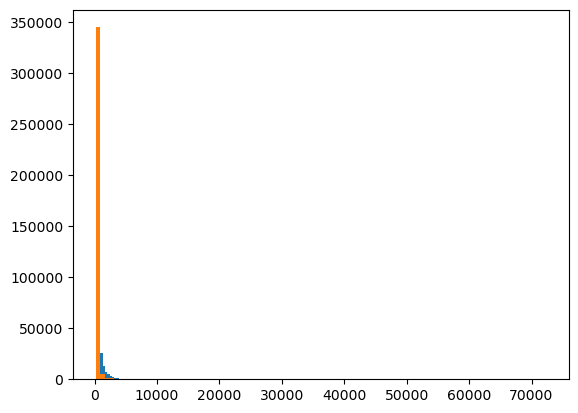

In [5]:
laura_data = summarise_distribution("/home2/lbb10k/transferred/berg01l/ngs/nextseq_nerc/data_dir/all_contigs.fa")
matt_data = summarise_distribution("/home3/2574106a/dump/all_contigs.fa")

In [45]:
pd.DataFrame({"lengths": laura_data[0]}).to_csv("/home3/2574106a/dump/laura_contig_lengths.csv")

In [19]:
dist = stats.poisson

contig_len_dist  = stats.fit(dist, laura_data[0], [(400,800)])

<Axes: title={'center': 'Fitted $\\tt poisson$ PMF and Histogram'}, xlabel='k', ylabel='PMF'>

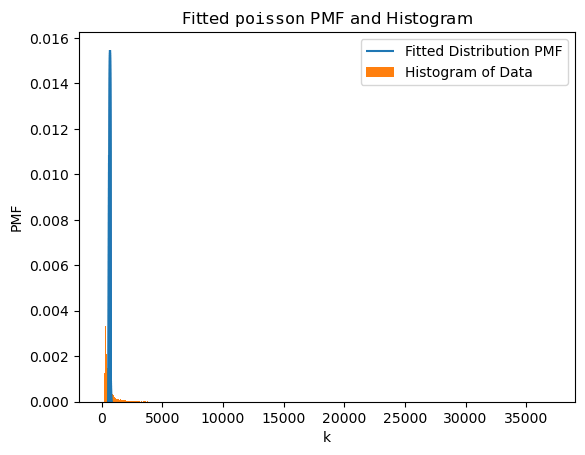

In [20]:
contig_len_dist.plot()

(array([3.60000e+01, 1.81700e+03, 2.89120e+04, 1.59330e+05, 3.64410e+05,
        3.17870e+05, 1.09312e+05, 1.72280e+04, 1.05500e+03, 3.00000e+01]),
 array([539. , 564.7, 590.4, 616.1, 641.8, 667.5, 693.2, 718.9, 744.6,
        770.3, 796. ]),
 <BarContainer object of 10 artists>)

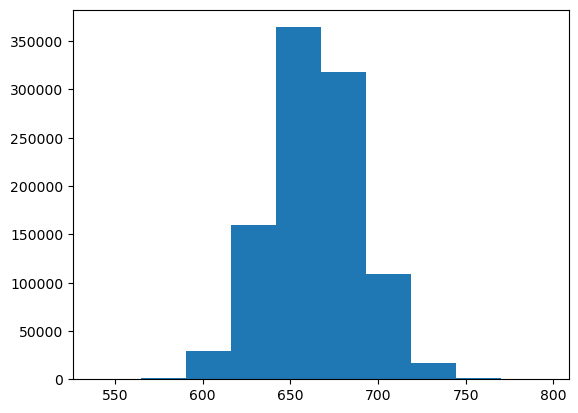

In [35]:
plt.hist(stats.poisson(664.1206984021566).rvs(1000000))

In [25]:
contig_len_dist

  params: FitParams(mu=np.float64(664.1206984021566), loc=np.float64(0.0))
 success: True
 message: 'Optimization terminated successfully.'